In [16]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
# Standard library imports
import sys
import os
import glob
from pathlib import Path

# Scientific and I/O libraries
import numpy as np
from scipy.io import loadmat
from scipy.stats import zscore
import pickle
import mat73
import h5py
# Add custom utilities to path
sys.path.append('/home/asantoro/research/')

# Custom and plotting imports
from utils_neuromaps_brain import normal_view 
from matplotlib import rcParams

import matplotlib.pyplot as plt

# Set matplotlib font preferences
rcParams["font.family"] = ["DejaVu Serif"]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# ## Simple way to load a mat file
# path='../../Data/002GNV/rsfMRI/FC_002GNV_Schaefer2018_all_subc_Reg2_dil2_m.mat'
# data=loadmat(path, struct_as_record=True, squeeze_me=True, simplify_cells=True)

###  Creating `{subjID}_TC_Schaefer.pkl` to save time courses of the rsfMRI with all the sessions

In [18]:
def is_mat_v7_3(path):
    """Return True if the .mat file is HDF5-based (MAT v7.3)."""
    # Check for HDF5 signature anywhere in the first 512 bytes (robust to header junk)
    with open(path, "rb") as f:
        header = f.read(512)
        return b"HDF" in header

def loadmat_any(path, *, struct_as_record=True, squeeze_me=True, simplify_cells=True):
    """
    Load MATLAB .mat files of any version.
    - Uses scipy.io.loadmat for v7.2 and earlier (Level 5).
    - Uses h5py for v7.3 (HDF5).
    Tries to keep behavior as similar as possible.
    """
    path = str(Path(path))
    if is_mat_v7_3(path):
        return mat73.loadmat(path)
    else:
        # Use scipy.io.loadmat for classic .mat files
        return loadmat(path, struct_as_record=struct_as_record, squeeze_me=squeeze_me, simplify_cells=simplify_cells)

data_path = '../../Data/'
data_out = '../../Cleaned/rsfMRI/'

# Find all .mat files matching the pattern in all subject rsfMRI folders
mat_files = glob.glob(os.path.join(data_path, '*', 'rsfMRI', 'FC_*_Schaefer2018_all_subc_Reg2_dil*_m.mat'))

for mat_file in mat_files:
    # Extract subjID from the path: ../../Data/048GNV/rsfMRI/FC_048GNV_Schaefer2018_all_subc_Reg2_dil2_m.mat
    subjID = os.path.basename(os.path.dirname(os.path.dirname(mat_file)))
    pickle_file = os.path.join(data_out, f'{subjID}_TC_Schaefer.pkl')
    if os.path.exists(pickle_file):
        print(f"Pickle for {subjID} already exists at {pickle_file}, skipping.")
        continue
    try:
        data = loadmat_any(mat_file, struct_as_record=True, squeeze_me=True, simplify_cells=True)
        subj_data = {}
        for key in data['TC_Schaefer_rsfMRI']:
            subj_data[key] = data['TC_Schaefer_rsfMRI'][key]
        # Save each subject's data as a pickle file
        with open(pickle_file, 'wb') as f:
            pickle.dump(subj_data, f)
        print(f"Saved pickle for {subjID} at {pickle_file}")
    except Exception as e:
        print(f"Error processing {subjID} ({mat_file}): {e}")

Pickle for 034GNV already exists at ../../Cleaned/rsfMRI/034GNV_TC_Schaefer.pkl, skipping.
Pickle for 012GNV already exists at ../../Cleaned/rsfMRI/012GNV_TC_Schaefer.pkl, skipping.
Pickle for 005GNV already exists at ../../Cleaned/rsfMRI/005GNV_TC_Schaefer.pkl, skipping.
Pickle for 043GNV already exists at ../../Cleaned/rsfMRI/043GNV_TC_Schaefer.pkl, skipping.
Pickle for 021GNV already exists at ../../Cleaned/rsfMRI/021GNV_TC_Schaefer.pkl, skipping.
Pickle for 037GNV already exists at ../../Cleaned/rsfMRI/037GNV_TC_Schaefer.pkl, skipping.
Pickle for 056GNV already exists at ../../Cleaned/rsfMRI/056GNV_TC_Schaefer.pkl, skipping.
Pickle for 026GNV already exists at ../../Cleaned/rsfMRI/026GNV_TC_Schaefer.pkl, skipping.
Pickle for 025GNV already exists at ../../Cleaned/rsfMRI/025GNV_TC_Schaefer.pkl, skipping.
Pickle for 013GNV already exists at ../../Cleaned/rsfMRI/013GNV_TC_Schaefer.pkl, skipping.
Pickle for 023GNV already exists at ../../Cleaned/rsfMRI/023GNV_TC_Schaefer.pkl, skipping.

###  Creating `rsfMRI_utils.pkl` to save important features of the rsfMRI

In [21]:
# rsfMRI_utils is a nested dictionary containing various indices and reference data for all participants.
# Explanation of the elements:
#   - 'AudROI': {'L': {}, 'R': {}}: Indices of auditory ROIs for left ('L') and right ('R') hemispheres, for each parcellation (100, 200, 400, 800). Not participant-specific.
#   - 'AudROIoverlap': {}: For each participant, contains the fraction of voxels in each auditory ROI that overlap with the original mask of activity (personalized per participant).
#   - 'FDindices': {}: For each participant, contains indices of fMRI volumes with framewise displacement (FD) >= 0.5, for each session.
#   - 'PCidx': {}: For each participant, contains indices of poor coverage (to be set as NaN), for each parcellation.
#   - 'yeo7': {}: Yeo7 network labels for each parcellation (not participant-specific).

data_path = '../../Data/'
data_out = '../../Cleaned/rsfMRI/'
pickle_file = os.path.join(data_out, 'rsfMRI_utils.pkl')

if not os.path.exists(pickle_file):  # Only process if the pickle does not already exist
    rsfMRI_utils = {
        'AudROI': {'L': {}, 'R': {}},      # Indices of auditory ROIs (not participant-specific)
        'AudROIoverlap': {},               # Fraction of overlap for each participant
        'FDindices': {},                   # FD >= 0.5 indices for each participant/session
        'PCidx': {},                       # Poor coverage indices for each participant/parcellation
        'yeo7': {}                         # Yeo7 network labels (not participant-specific)
    }

    # Find all .mat files matching the pattern in all subject rsfMRI folders
    mat_files = glob.glob(os.path.join(data_path, '*', 'rsfMRI', 'FC_*_Schaefer2018_all_subc_Reg2_dil*_m.mat'))

    audroi_done = False  # Only fill AudROI and yeo7 once, as they are not participant-specific

    for mat_file in mat_files:
        # Extract subjID from the path: ../../Data/048GNV/rsfMRI/FC_048GNV_Schaefer2018_all_subc_Reg2_dil2_m.mat
        subjID = os.path.basename(os.path.dirname(os.path.dirname(mat_file)))
        try:
            data = loadmat_any(mat_file, struct_as_record=True, squeeze_me=True, simplify_cells=True)  # Load .mat file

            if not audroi_done:
                for parc in [100, 200, 400, 800]:
                    rsfMRI_utils['AudROI']['L'][parc] = data['inds_ROIs_overlapping_Schaefer_rsfMRI']['AudROI_L'][f'r{parc}']
                    rsfMRI_utils['AudROI']['R'][parc] = data['inds_ROIs_overlapping_Schaefer_rsfMRI']['AudROI_R'][f'r{parc}']
                    rsfMRI_utils['yeo7'][parc] = data['yeo7'][f'r{parc}']
                audroi_done = True  # Only do this once

            # Save the indices of the fMRI volumes with FD >= 0.5 for this participant
            nsessions = data['skipped_FDs_frames_rsfMRI'].shape[1]
            rsfMRI_utils['FDindices'][subjID] = {}
            for s in range(1,nsessions+1):
                currentFD = data['skipped_FDs_frames_rsfMRI'][:, s-1]
                if np.all(np.isnan(currentFD)):
                    result = np.nan
                elif np.all(currentFD == 0):
                    result = np.array([])
                else:
                    result = np.array(currentFD[np.nonzero(currentFD)[0]])-1
                rsfMRI_utils['FDindices'][subjID][f'V{s:02d}'] = result  # Store FD indices for this session

            # For each auditory parcel, store the fraction of voxels in overlap with the original mask (per participant)
            together = {
                'L': {100: {}, 200: {}, 400: {}, 800: {}},
                'R': {100: {}, 200: {}, 400: {}, 800: {}}
            }
            for parc in [100, 200, 400, 800]:
                together['L'][parc] = data['inds_ROIs_overlapping_Schaefer_rsfMRI']['AudROI_L'][f'r{parc}_percoverlap']
                together['R'][parc] = data['inds_ROIs_overlapping_Schaefer_rsfMRI']['AudROI_R'][f'r{parc}_percoverlap']
            rsfMRI_utils['AudROIoverlap'][subjID] = together  # Store overlap info for this participant

            # Poor Coverage indices for this participant
            rsfMRI_utils['PCidx'][subjID] = {}
            for parc in [100, 200, 400, 800]:
                rsfMRI_utils['PCidx'][subjID][parc] = data['inds_to_NaN_rsfMRI'][f'r{parc}']  # Store PC indices

            print(f"Processed {subjID}")

        except Exception as e:
            print(f"Error processing {subjID} ({mat_file}): {e}")

    # Save the complete rsfMRI_utils dictionary as a single pickle file for all participants
    with open(pickle_file, 'wb') as f:
        pickle.dump(rsfMRI_utils, f)  # Save all participants' info in one file
    print(f"Saved rsfMRI_utils for all participants at {pickle_file}")
else:
    print(f"rsfMRI_utils.pkl already exists at {pickle_file}, skipping processing and reading directly")
    with open(pickle_file, 'rb') as f:
        rsfMRI_utils=pickle.load(f)

# ---------------------------------------------------------------------------
# User Guide: Structure of rsfMRI_utils
#
# rsfMRI_utils = {
#     'AudROI': {
#         'L': {parc: indices, ...},   # Auditory ROI indices for left hemisphere (not participant-specific)
#         'R': {parc: indices, ...}    # Auditory ROI indices for right hemisphere (not participant-specific)
#     },
#     'AudROIoverlap': {
#         subjID: {
#             'L': {parc: overlap_fraction, ...},  # Fraction of overlap for left hemisphere, per parcellation
#             'R': {parc: overlap_fraction, ...}   # Fraction of overlap for right hemisphere, per parcellation
#         },
#         ...
#     },
#     'FDindices': {
#         subjID: {
#             'V00': array or nan,   # Indices of FD >= 0.5 for session 0
#             'V01': array or nan,   # Indices of FD >= 0.5 for session 1
#             ...
#         },
#         ...
#     },
#     'PCidx': {
#         subjID: {
#             parc: indices,         # Poor coverage indices for this parcellation
#             ...
#         },
#         ...
#     },
#     'yeo7': {
#         parc: array,              # Yeo7 network labels for each parcellation (not participant-specific)
#         ...
#     }
# }
# - subjID: participant identifier (e.g., '048GNV')
# - parc: parcellation granularity (100, 200, 400, 800)
# - indices: array of indices (or nan/empty array) as appropriate
# - overlap_fraction: fraction of overlap for each auditory ROI
# ---------------------------------------------------------------------------


Processed 034GNV
Processed 012GNV
Processed 005GNV
Processed 043GNV
Processed 021GNV
Processed 037GNV
Processed 056GNV
Processed 026GNV
Processed 025GNV
Processed 013GNV
Processed 023GNV
Processed 020GNV
Processed 054GNV
Processed 008GNV
Processed 049GNV
Processed 048GNV
Processed 016GNV
Processed 041GNV
Processed 004GNV
Processed 002GNV
Processed 003GNV
Saved rsfMRI_utils for all participants at ../../Cleaned/rsfMRI/rsfMRI_utils.pkl


### Loading the data

In [4]:

data_out = '../../Cleaned/rsfMRI'

data_all = {}
pickle_files = glob.glob(os.path.join(data_out, '*_TC_Schaefer.pkl'))

for pf in pickle_files:
    subjID = os.path.basename(pf).split('_TC_Schaefer.pkl')[0]
    with open(pf, 'rb') as f:
        data_all[subjID] = pickle.load(f)


### Example: Compute and plot the correlation matrix heatmap for subject '008GNV', session 'V01_400'

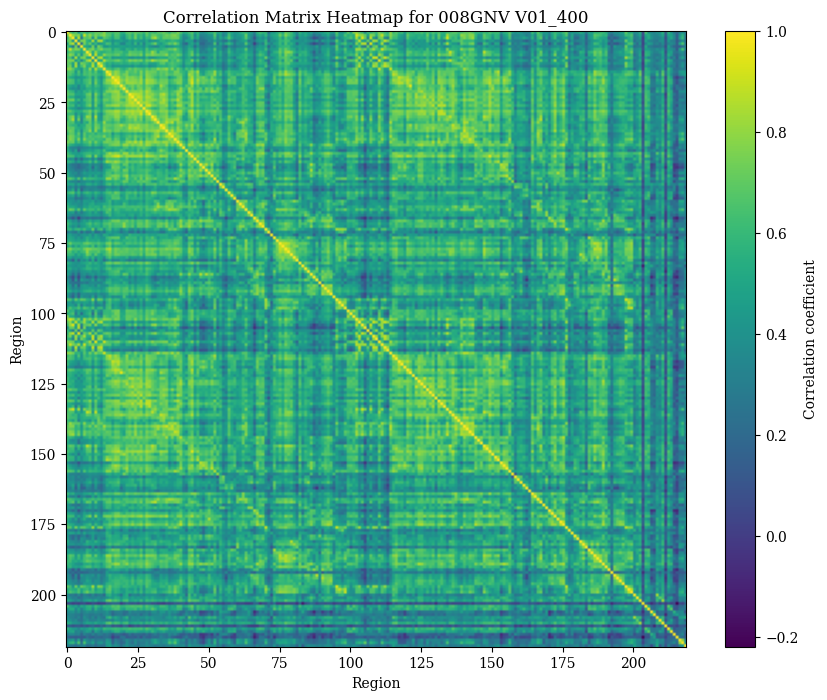

In [ ]:
# Compute the correlation matrix for the time series data of subject '008GNV', session 'V01_400'
corr_matrix = np.corrcoef(data_all['008GNV']['V01_200'].T)

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Correlation coefficient')
plt.title("Correlation Matrix Heatmap for 008GNV V01_400")
plt.xlabel("Region")
plt.ylabel("Region")
plt.show()

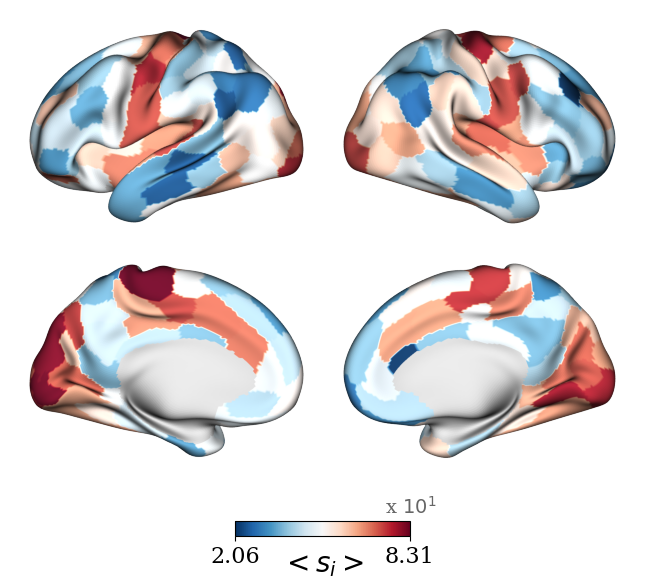

In [15]:
### Plotting the nodal strength (you need to stop at 200-> only cortical regions)
normal_view(np.sum(corr_matrix,axis=1)[:200],parcellation=200);

### Compute the subject-session pair comparison to create the Identifiability matrix

In [11]:
# Step 1: Get sorted list of subject IDs
subject_ids = sorted(data_all.keys())
parc_sel='200'
# Step 2: Collect all unique session names containing the given parcellation across all subjects, then sort them
session_names = sorted({k for subj in subject_ids for k in data_all[subj].keys() if parc_sel in k})

# Step 3: Prepare containers for upper triangle vectors, labels, and session counts per subject
upper_tri_vectors = []  # Will hold the upper triangle of each correlation matrix
labels = []             # Will hold subject_session labels for each vector
count_subjs_session = {subj: 0 for subj in subject_ids}  # Track number of sessions per subject

# Step 4: For each subject and each session, extract the upper triangle of the correlation matrix
for subj in subject_ids:
    for sess in session_names:
        if sess in data_all[subj]:
            # Increment session count for this subject
            count_subjs_session[subj] += 1
            # Compute correlation matrix for the session's time series (regions x timepoints)
            corr_matrix = np.nan_to_num(np.corrcoef(data_all[subj][sess].T))
            # Extract the upper triangle (excluding the diagonal) as a 1D vector
            upper_tri = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
            upper_tri_vectors.append(upper_tri)
            # Store the label for this subject-session pair
            labels.append(f"{subj}_{sess}")

# Step 5: Convert list of upper triangle vectors to a numpy array (n_pairs x n_features)
upper_tri_vectors = np.array(upper_tri_vectors)

# Step 6: Compute the correlation matrix between all subject-session pairs (the fingerprinting matrix)
big_corr_matrix = np.corrcoef(upper_tri_vectors)


/home/asantoro/anaconda3/envs/tinnitus/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/asantoro/anaconda3/envs/tinnitus/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [12]:
### Notice: not all the subjects have the same number of resting-state sessions
count_subjs_session

{'002GNV': 14,
 '003GNV': 14,
 '004GNV': 15,
 '005GNV': 15,
 '008GNV': 15,
 '012GNV': 15,
 '013GNV': 15,
 '016GNV': 15,
 '020GNV': 15,
 '021GNV': 15,
 '023GNV': 15,
 '025GNV': 15,
 '026GNV': 15,
 '034GNV': 15,
 '037GNV': 15,
 '041GNV': 15,
 '043GNV': 15,
 '048GNV': 15,
 '049GNV': 15,
 '054GNV': 15,
 '056GNV': 15}

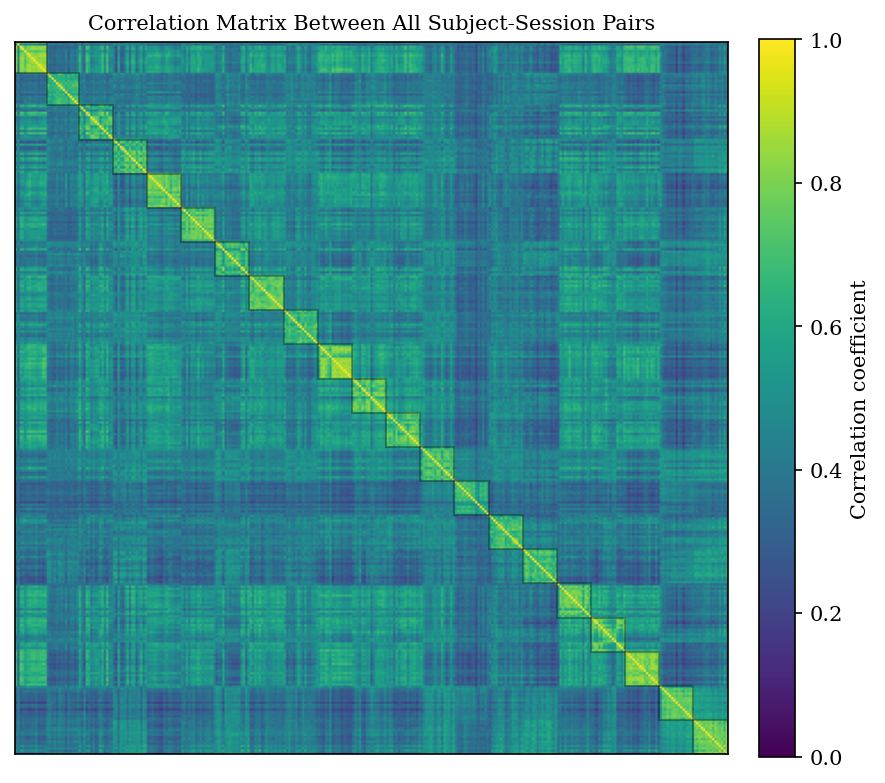

In [14]:
plt.figure(figsize=(6,6),dpi=150)
im = plt.imshow(big_corr_matrix, cmap='viridis', vmin=0, vmax=1)  # Set aspect to 'square'
plt.colorbar(im, fraction=0.046, pad=0.04, label='Correlation coefficient')
plt.title("Correlation Matrix Between All Subject-Session Pairs",fontsize=10)
plt.xticks([])
plt.yticks([])

# Draw boxes along the diagonal to highlight each subject's block
block_sizes = []
for subj in sorted(data_all.keys()):
    count = sum([1 for sess in session_names if sess in data_all[subj]])
    block_sizes.append(count)

start = 0
for size in block_sizes:
    end = start + size
    rect = plt.Rectangle((start-0.5, start-0.5), size, size, fill=False, edgecolor='k', linewidth=1,alpha=0.3)
    plt.gca().add_patch(rect)
    start = end

plt.tight_layout()
plt.show()